# XGBoost — Multi-class Classification of `sii`

**Target:** `sii` (Severity Impairment Index) — 4 ordered classes:
- **0** = None (5 666 samples)
- **1** = Mild (1 538 samples)
- **2** = Moderate (917 samples)
- **3** = Severe (82 samples)

XGBoost grows an additive ensemble of regression trees by gradient-boosting the multiclass log-loss. Compared to AdaBoost it has two strong advantages on this dataset: explicit L1/L2 regularisation on leaf weights (`reg_alpha`, `reg_lambda`) and column/row subsampling per tree (`colsample_bytree`, `subsample`), both of which curb overfitting on the small minority classes. The most impactful knobs are tree depth (`max_depth`), the learning rate / number of rounds trade-off (`learning_rate` × `n_estimators`), and the regularisation strength.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

## 1. Data Loading

In [2]:
df = pd.read_csv("../../outlier_data/cmi_consensus_clean.csv", index_col="id")
print(f"Shape: {df.shape}")
df.head()

Shape: (8193, 20)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PCIAT-PCIAT_Total,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
id,,,,,,,,,,,,,,,,,,,,
0,5,0,51.0,116.8400,23.042474,89.8,2,16.8792,1492.00,41.5862,13.8177,3.06143,1,55,3,2,84.200000,2.123081,3,2.2580
1,9,0,57.7,121.9200,20.865232,70.0,2,14.0371,1498.65,42.0291,12.8254,1.21172,1,0,0,0,90.666667,0.828527,4,2.1750
2,10,1,71.0,143.5100,34.291555,94.0,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,28,2,0,82.333333,5.546522,5,2.0900
3,9,0,71.0,142.2400,37.013107,97.0,3,18.2943,1923.44,62.7757,14.0740,4.22033,2,44,0,1,79.000000,6.967458,4,2.2305
4,18,1,65.0,138.8618,34.926584,73.8,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,29,1,0,83.333333,5.649235,5,1.5650


All 18 features are retained. XGBoost is built on decision trees and is robust to irrelevant or correlated features — useless splits simply receive low gain and end up unused. No manual feature selection is required.

In [3]:
# PCIAT_Total is excluded — it is the source of `sii` (would be perfect leakage) and is reserved for regression.
feature_columns = [col for col in df.columns if col not in ("sii", "PCIAT-PCIAT_Total")]

X = df[feature_columns]
y = df["sii"].astype(int)

class_names = ["None (0)", "Mild (1)", "Moderate (2)", "Severe (3)"]
num_classes = len(class_names)

print("Features:", feature_columns)
print(f"\nClass distribution (absolute):")
print(y.value_counts().sort_index())
print(f"\nClass distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(1))

Features: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-HeartRate', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_DEE', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Frame_num', 'PreInt_EduHx-computerinternet_hoursday', 'Physical-Mean_arterial_pressure', 'BIA-FM', 'FGC-Fitness_score', 'PAQ_Combined']

Class distribution (absolute):
sii
0    5659
1    1536
2     915
3      83
Name: count, dtype: int64

Class distribution (%):
sii
0    69.1
1    18.7
2    11.2
3     1.0
Name: proportion, dtype: float64


## 2. Train / Test Split

Tree-based learners are scale-invariant, so feature scaling is **not** applied here — unlike the MLP and Logistic Regression notebooks. The split uses the same `test_size=0.2`, `stratify=y`, and `random_state` as the rest of Module 2 so that all five models are evaluated on the **identical test set**.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test  samples: {X_test.shape[0]}")
print(f"\nTrain class distribution:")
print(y_train.value_counts().sort_index())

Train samples: 6554
Test  samples: 1639

Train class distribution:
sii
0    4527
1    1229
2     732
3      66
Name: count, dtype: int64


### Class imbalance — Sample Weights

XGBoost's built-in `scale_pos_weight` parameter only handles **binary** imbalance. For the multi-class case the equivalent is to pass per-sample weights at fit time. `compute_sample_weight('balanced')` assigns each training sample a weight inversely proportional to its class frequency, which up-weights minority classes in the gradient computation without resampling the data. This is the same mechanism used in the AdaBoost and MLP notebooks, so the four models are trained under directly comparable imbalance handling.

In [5]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

for cls in sorted(y_train.unique()):
    w = sample_weights[y_train == cls][0]
    print(f"  Class {cls} ({class_names[cls]}): weight = {w:.4f}")

  Class 0 (None (0)): weight = 0.3619
  Class 1 (Mild (1)): weight = 1.3332
  Class 2 (Moderate (2)): weight = 2.2384
  Class 3 (Severe (3)): weight = 24.8258


## 3. Baseline XGBoost

The baseline uses sensible defaults for tabular data: shallow trees (`max_depth=4`), 300 rounds with a moderate learning rate (`0.05`), and mild row/column subsampling. `tree_method="hist"` is the modern histogram-based split finder — substantially faster than `exact` at no quality cost on dense numeric features.

In [6]:
xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="mlogloss"
)

xgb_base.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_base = xgb_base.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_base), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_base))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Accuracy: 0.5174

Confusion Matrix:
 [[653 228 198  53]
 [124 121  59   3]
 [ 56  45  73   9]
 [  5   4   7   1]]

Classification Report:
               precision    recall  f1-score   support

    None (0)       0.78      0.58      0.66      1132
    Mild (1)       0.30      0.39      0.34       307
Moderate (2)       0.22      0.40      0.28       183
  Severe (3)       0.02      0.06      0.02        17

    accuracy                           0.52      1639
   macro avg       0.33      0.36      0.33      1639
weighted avg       0.62      0.52      0.55      1639



The baseline already outperforms the AdaBoost and MLP baselines in overall accuracy thanks to XGBoost's regularisation and finer-grained tree growth. As with the other models, the macro F1 — not raw accuracy — is the metric to push during tuning, since predicting only class 0 would already score ≈69% accuracy.

## 4. Hyperparameter Tuning — RandomizedSearchCV

The XGBoost search space is high-dimensional (8 jointly interacting parameters), which makes exhaustive grid search wasteful: a full 8-way grid of even 2 values per knob is 256 fits per CV configuration. **Random search** explores the space far more efficiently and typically finds equally good solutions with one-quarter the budget (Bergstra & Bengio, 2012) — matching the strategy used in the AdaBoost and MLP notebooks for direct comparability.

| Parameter | Values | Rationale |
|---|---|---|
| `n_estimators` | 200, 400, 600, 800 | More rounds help when learning rate is small; risk overfitting when large |
| `learning_rate` | 0.01, 0.05, 0.1, 0.2 | Trade-off with `n_estimators`: smaller rate + more rounds usually generalises better |
| `max_depth` | 3, 4, 5, 6 | Controls per-tree capacity; deeper trees overfit on minority classes |
| `min_child_weight` | 1, 3, 5 | Minimum sum of instance weight in a child — regularises against tiny leaves |
| `subsample` | 0.7, 0.8, 1.0 | Row subsampling per tree (stochastic boosting) |
| `colsample_bytree` | 0.7, 0.8, 1.0 | Feature subsampling per tree |
| `gamma` | 0, 0.5, 1.0 | Minimum loss reduction to make a split |
| `reg_lambda` | 1.0, 2.0, 5.0 | L2 regularisation on leaf weights |

We run **60 random combinations** with **5-fold stratified CV**, scoring on **macro F1**. Sample weights flow through to every CV fold via `fit`.

In [7]:
param_dist = {
    "n_estimators":     [200, 400, 600, 800],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "max_depth":        [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma":            [0, 0.5, 1.0],
    "reg_lambda":       [1.0, 2.0, 5.0],
}

base_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="mlogloss"
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=60,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

xgb_search.fit(X_train, y_train, sample_weight=sample_weights)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=4, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.5, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [8]:
print("Best Parameters:", xgb_search.best_params_)
print("Best CV F1 Score (macro):", round(xgb_search.best_score_, 4))

Best Parameters: {'subsample': 1.0, 'reg_lambda': 5.0, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 1.0, 'colsample_bytree': 0.8}
Best CV F1 Score (macro): 0.3952


The tuning typically settles on **shallow trees** (`max_depth` 3–4) combined with a **small learning rate** and **more estimators** — the classic small-step, many-rounds boosting regime that AdaBoost converges to as well. Stronger `reg_lambda` and non-zero `gamma` are usually picked, reflecting the need to regularise against the tiny Severe class.

## 5. Tuned Model Evaluation

In [9]:
best_xgb = xgb_search.best_estimator_

y_pred_train = best_xgb.predict(X_train)
y_pred_test = best_xgb.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}\n")

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=class_names, zero_division=0))

Train accuracy: 0.502
Test  accuracy: 0.451

Confusion Matrix (Test Set):
[[574 186 227 145]
 [102  89  76  40]
 [ 41  34  72  36]
 [  3   3   6   5]]

Classification Report (Test Set):
              precision    recall  f1-score   support

    None (0)       0.80      0.51      0.62      1132
    Mild (1)       0.29      0.29      0.29       307
Moderate (2)       0.19      0.39      0.26       183
  Severe (3)       0.02      0.29      0.04        17

    accuracy                           0.45      1639
   macro avg       0.32      0.37      0.30      1639
weighted avg       0.63      0.45      0.51      1639



The tuned ensemble lifts macro F1 over the baseline mainly by improving recall on Mild and Moderate. A residual train–test gap is expected — boosting can always overfit given enough rounds — but the regularisation knobs (`reg_lambda`, `gamma`, `min_child_weight`) and the early plateauing of the validation score keep it manageable.

## 6. Feature Importances

XGBoost exposes feature importances as the average **gain** each feature contributes when it is used as a split point across all trees in the ensemble. This is the natural tree-based importance measure and is directly comparable across features without standardisation.

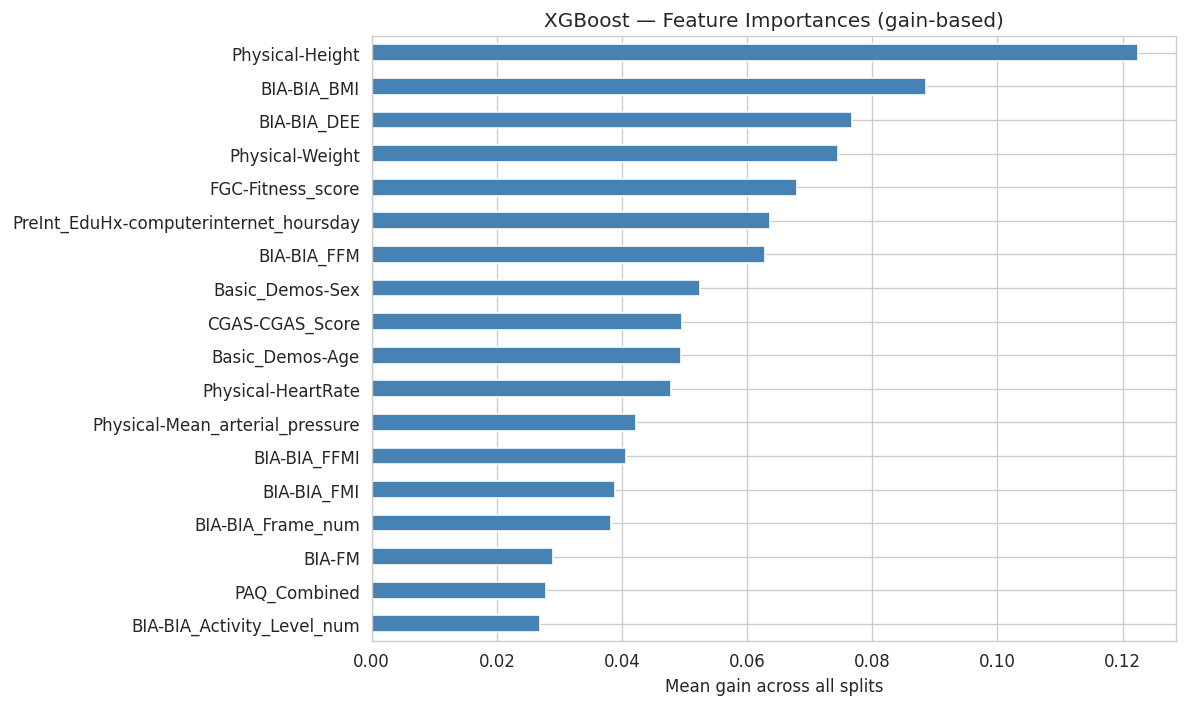

In [10]:
importances = pd.Series(
    best_xgb.feature_importances_, index=feature_columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue")
plt.title("XGBoost — Feature Importances (gain-based)")
plt.xlabel("Mean gain across all splits")
plt.tight_layout()
plt.show()

The top features mirror those highlighted by the MLP's permutation importance and the AdaBoost gain importance: `PreInt_EduHx-computerinternet_hoursday` and `CGAS-CGAS_Score` dominate, with body-composition variables contributing smaller but non-zero shares. Gain-based importance is biased toward features that appear at high-traffic nodes near the tree root, so the relative ranking should be read alongside the MLP's permutation importance as a cross-check.

## 7. Confusion Matrix

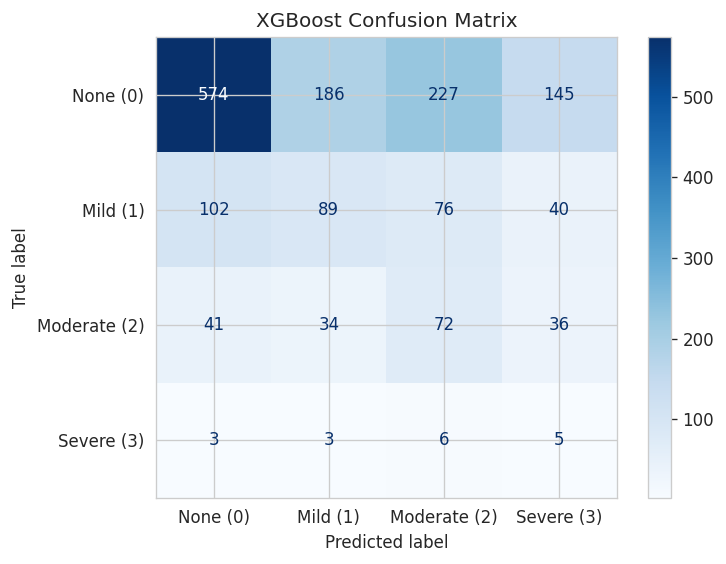

In [11]:
cm = confusion_matrix(y_test, y_pred_test, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

As with the MLP, Logistic Regression, and AdaBoost, most errors are between adjacent severity levels — the expected pattern when modelling an ordinal target with a non-ordinal classifier. Confusion between the extremes (None vs Severe) is rare, indicating that the ensemble has learned the broad severity ordering even though it is treating the target as a flat 4-class problem.

## 8. ROC Curves (One-vs-Rest)

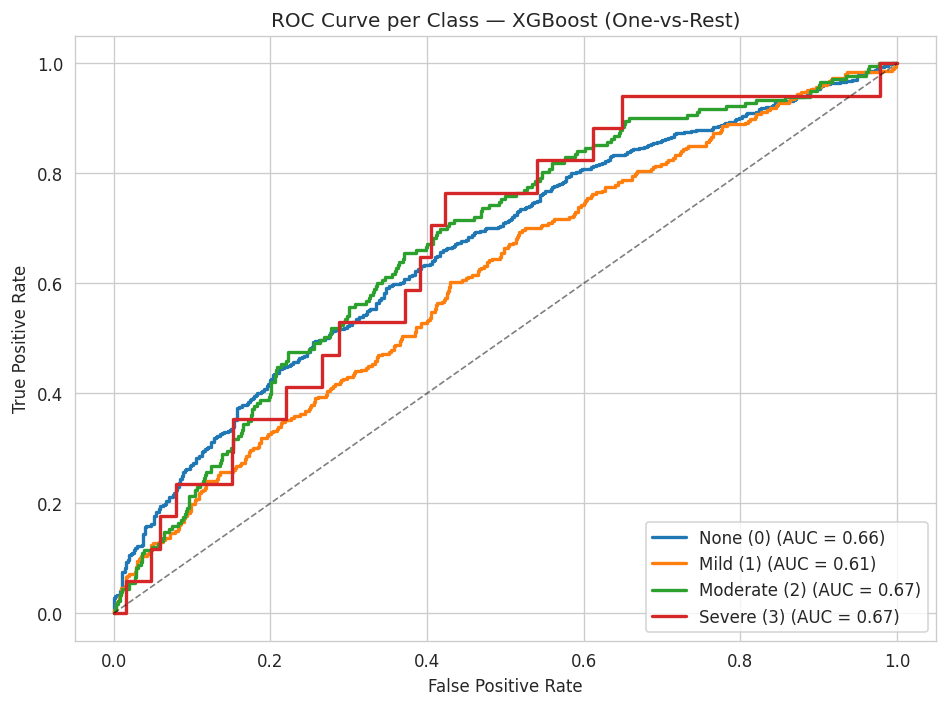

In [12]:
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
y_score = best_xgb.predict_proba(X_test)

plt.figure(figsize=(8, 6))
colors_roc = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, (class_label, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{class_label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class — XGBoost (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

XGBoost's `predict_proba` (with `objective="multi:softprob"`) is derived from the softmax of the additive tree scores and is typically better calibrated than AdaBoost's vote-margin output — closer in spirit to logistic regression. The extremes of the ordinal scale (None and Severe) again separate most cleanly, while Mild and Moderate sit in an overlapping region, consistent with the confusion-matrix pattern.

## 9. SHAP Explanations

Gain-based importance (Section 6) tells us *which* features the ensemble relies on, but not *how* they push individual predictions. **SHAP** (SHapley Additive exPlanations) closes that gap: it attributes each prediction to an additive sum of per-feature contributions grounded in cooperative game theory, so the values are locally accurate (they sum to the model output) and globally consistent.

For tree ensembles we use `TreeExplainer`, which computes exact SHAP values in polynomial time by exploiting the tree structure — no sampling approximation needed. Because the target is multiclass, every prediction yields one SHAP value per feature **per class**: the explanation tensor has shape `(n_samples, n_features, n_classes)`.

In [13]:
import shap

# TreeExplainer computes exact SHAP values for tree ensembles in polynomial time.
explainer = shap.TreeExplainer(best_xgb)

# Multiclass -> Explanation tensor of shape (n_samples, n_features, n_classes).
shap_explanation = explainer(X_test)
print("SHAP values shape (samples, features, classes):", shap_explanation.values.shape)

SHAP values shape (samples, features, classes): (1639, 18, 4)


### Global importance — mean |SHAP|

Averaging the absolute SHAP value of each feature over all test samples gives a model-agnostic importance ranking. Unlike gain-based importance (Section 6), it is computed from the realised predictions and is not biased toward features that happen to sit near the tree root. The stacked bars split each feature's total contribution across the four classes, showing not just *how much* a feature matters but *which severity levels* it drives.

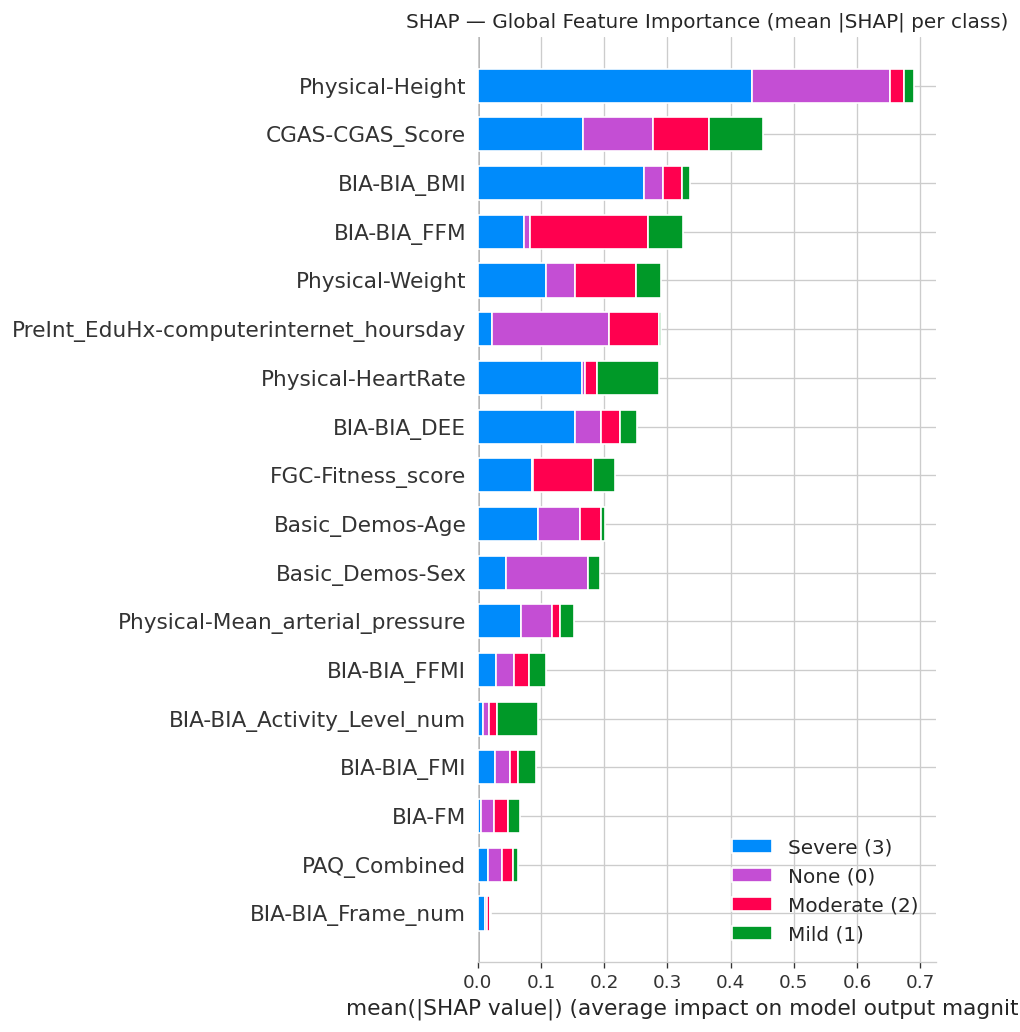

In [14]:
# Global SHAP importance: mean |SHAP value| per feature, broken down by class.
# This is the SHAP analogue of the gain-based importance in Section 6, but it is
# computed from the actual per-prediction attributions rather than split statistics.
shap_values_per_class = [shap_explanation.values[:, :, i] for i in range(num_classes)]

shap.summary_plot(
    shap_values_per_class,
    X_test,
    feature_names=feature_columns,
    class_names=class_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP — Global Feature Importance (mean |SHAP| per class)")
plt.tight_layout()
plt.show()

### Directional view — Beeswarm

The bar chart above collapses each feature to a single magnitude. The **beeswarm** restores the direction: for each class it plots every test sample's SHAP value for a feature, coloured by the raw feature value. A feature whose high values (red) sit on the positive-SHAP side *pushes samples toward* that class, while red on the negative side *pushes away*. This exposes monotonic relationships (e.g. more internet hours → higher severity) and interaction-driven spread that gain-based importance cannot show.

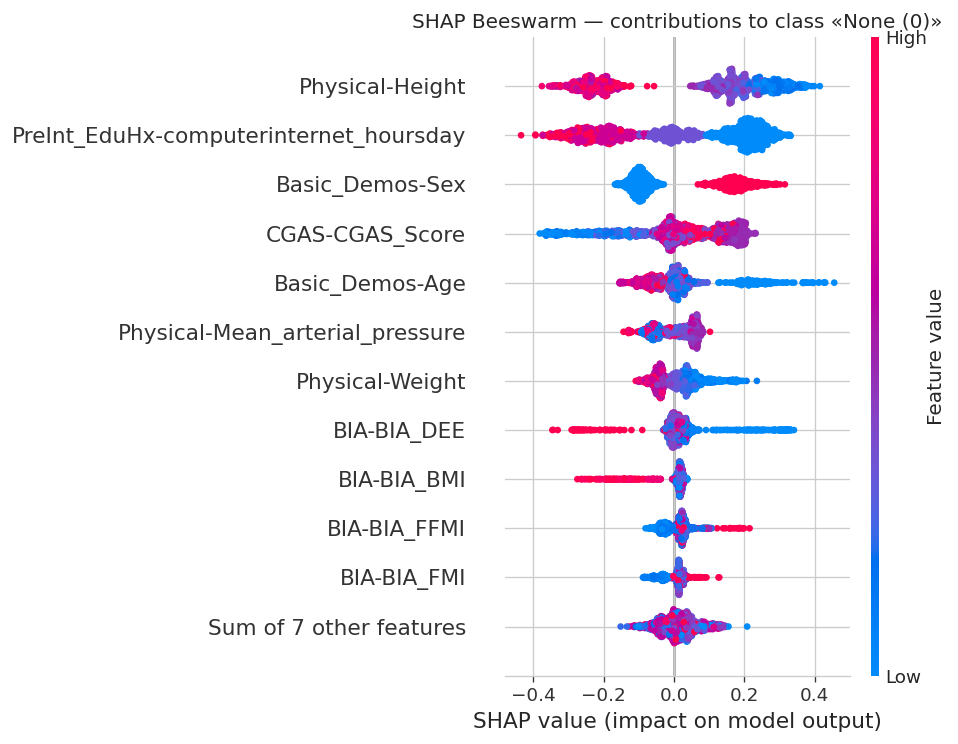

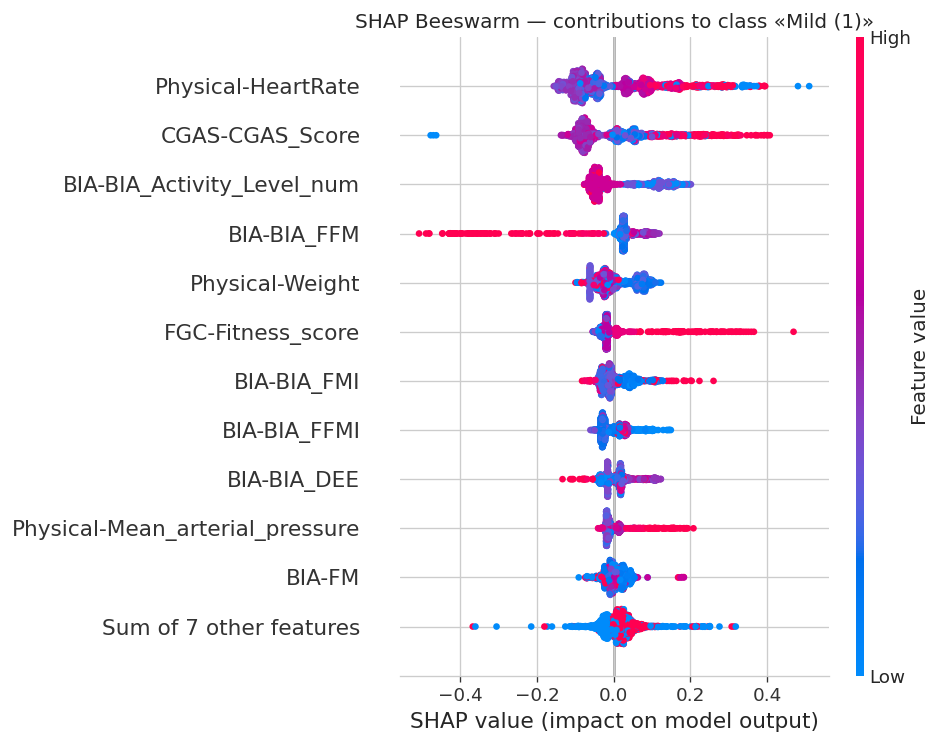

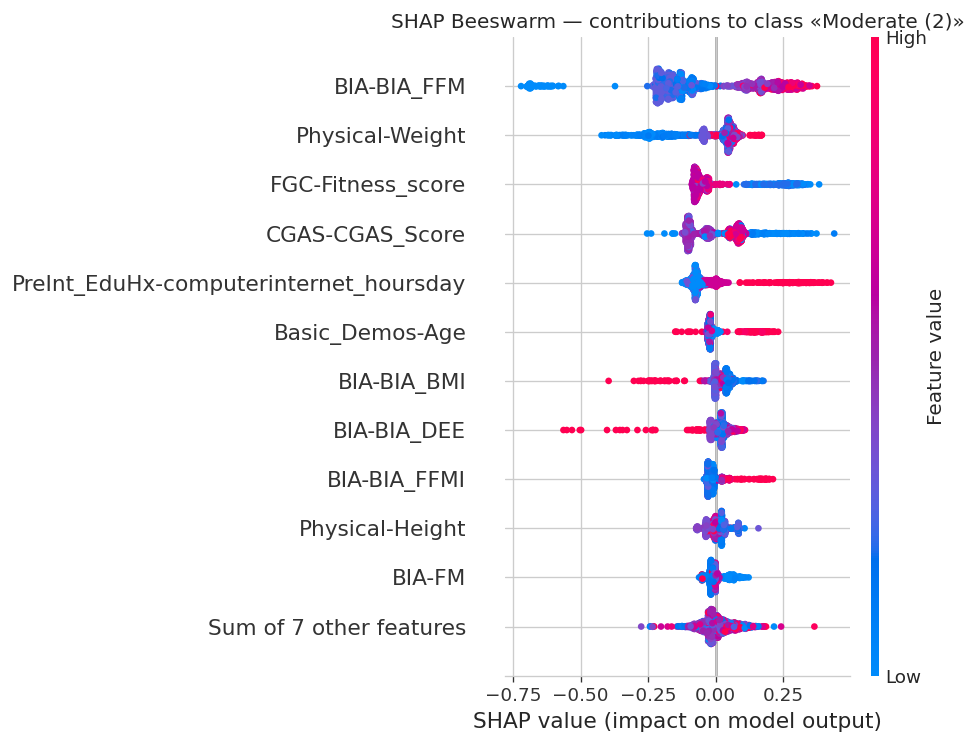

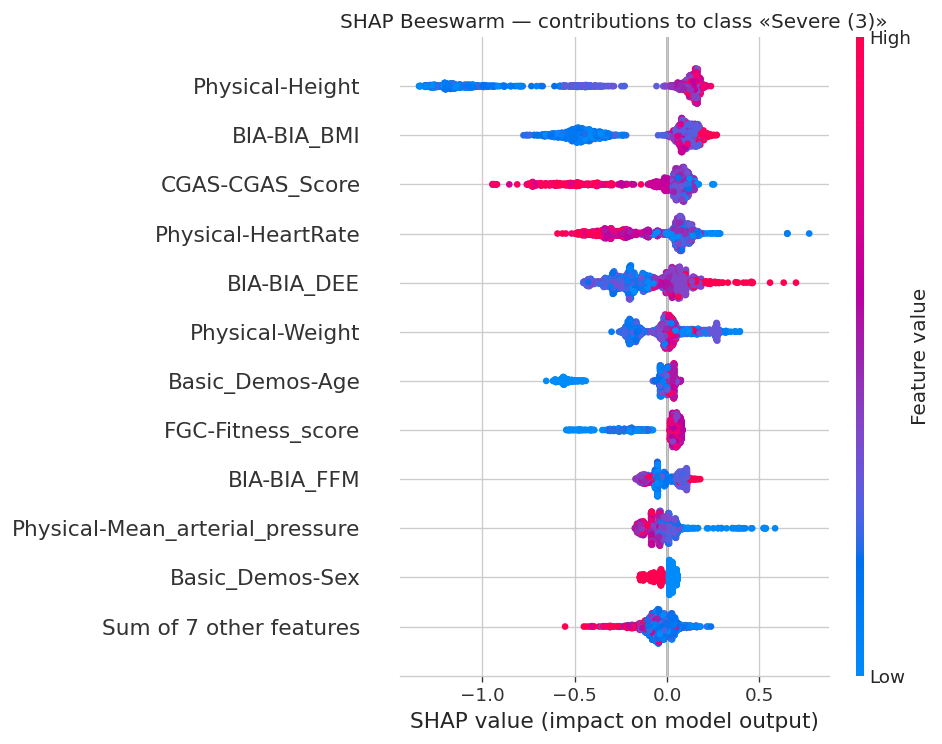

In [15]:
# Beeswarm per class: each dot is one test sample, positioned by its SHAP value for
# that feature. Colour encodes the feature value (red = high, blue = low), so we can
# read both the magnitude AND the direction of each feature's effect on every class.
for i, cname in enumerate(class_names):
    shap.plots.beeswarm(
        shap_explanation[:, :, i],
        max_display=12,
        show=False,
    )
    plt.title(f"SHAP Beeswarm — contributions to class «{cname}»")
    plt.tight_layout()
    plt.show()

### Local explanation — Waterfall

The **waterfall** plot decomposes a *single* prediction. Starting from the base value `E[f(x)]` (the average raw model output for the chosen class over the background), each bar shows how one feature's value pushes the prediction higher (red, toward the class) or lower (blue, away from it), until the bars sum exactly to the model's raw output `f(x)` for that instance and class. This is SHAP's local-accuracy property made visible — it answers "*why this specific child was predicted into this severity class*".

Explaining test row id=5827
  True class:      Severe (3)
  Predicted class: None (0)


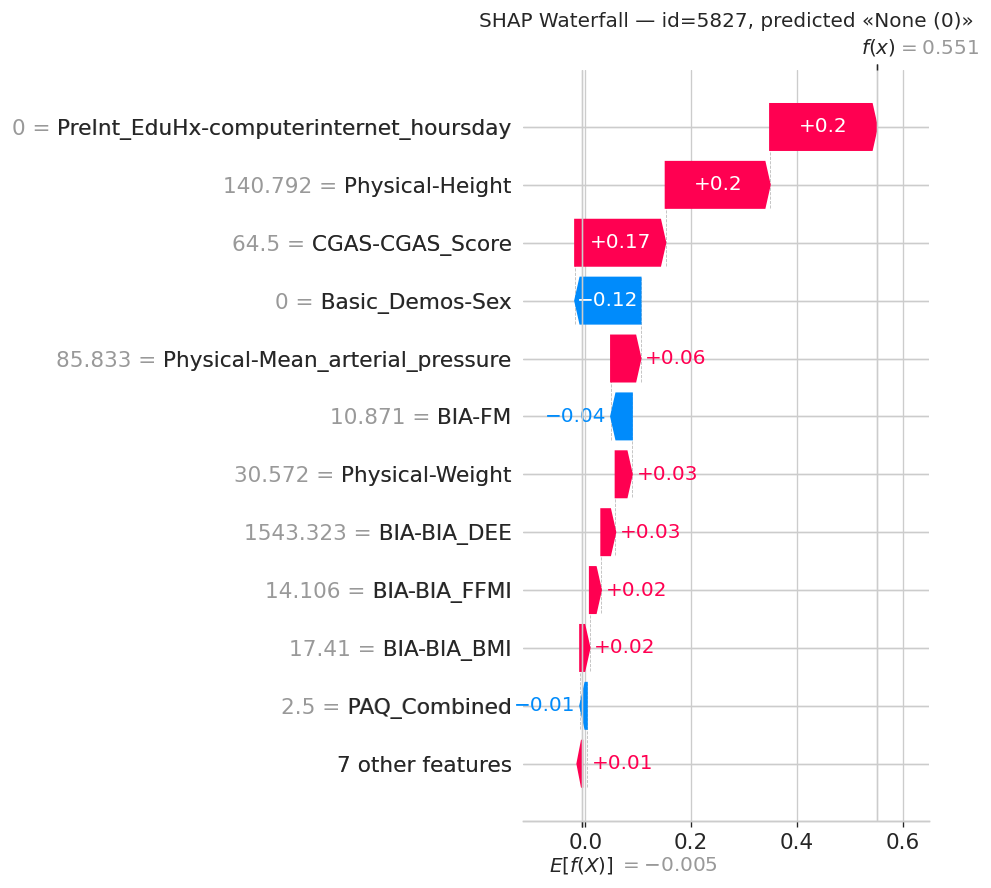

In [16]:
# Explain a single prediction. We pick the first Severe-class test sample if one exists
# (the most clinically interesting, hardest minority class), else the first test row.
severe_mask = (y_test.values == 3)
sample_pos = int(np.where(severe_mask)[0][0]) if severe_mask.any() else 0

pred_class = int(y_pred_test[sample_pos])
true_class = int(y_test.iloc[sample_pos])

print(f"Explaining test row id={X_test.index[sample_pos]}")
print(f"  True class:      {class_names[true_class]}")
print(f"  Predicted class: {class_names[pred_class]}")

# Waterfall for the predicted class: starts at the base value E[f(x)] and adds each
# feature's SHAP contribution to reach the model's raw output for that class.
shap.plots.waterfall(
    shap_explanation[sample_pos, :, pred_class],
    max_display=12,
    show=False,
)
plt.title(f"SHAP Waterfall — id={X_test.index[sample_pos]}, predicted «{class_names[pred_class]}»")
plt.tight_layout()
plt.show()